# Proyek Analisis Data: Bike Sharing Dataset 🚲
- **Nama:** Ari Rahmat Romadhon
- **Email:** arirahmatromadhon@gmail.com
- **ID Dicoding:** arighmt67


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1 (Pengaruh Cuaca):** Bagaimana variasi kondisi cuaca (*Clear/Partly Cloudy*, *Mist/Cloudy*, *Light Snow/Rain*) memengaruhi rata-rata jumlah peminjaman sepeda harian selama periode 2011–2012?
  - *Specific:* Fokus pada perbandingan metrik rata-rata peminjaman sepeda harian (`cnt`) antar kategori cuaca.
  - *Measurable:* Diukur menggunakan angka rata-rata dan total unit terpinjam per hari.
  - *Action-Oriented:* Memberikan dasar untuk perencanaan pemeliharaan armada dan penyesuaian tarif dinamis saat cuaca ekstrem.
  - *Relevant:* Berdampak langsung pada utilisasi aset dan pendapatan sistem *bike sharing*.
  - *Time-bound:* Dibatasi pada data historis tahun 2011 hingga 2012.

- **Pertanyaan 2 (Pola Jam & Hari Kerja):** Bagaimana disparitas pola volume peminjaman sepeda per jam antara hari kerja (*working day*) dan hari libur/akhir pekan (*non-working day*) pada pengguna kasual (*casual*) dibandingkan pengguna terdaftar (*registered*)?
  - *Specific:* Mengurai fluktuasi peminjaman sepeda pada 24 jam operasional untuk hari kerja vs akhir pekan.
  - *Measurable:* Dihitung berdasarkan rata-rata unit terpinjam per jam (`hr`) per kelompok pengguna (`casual` vs `registered`).
  - *Action-Oriented:* Menjadi acuan teknis dalam strategi *rebalancing* armada sepeda antar stasiun di jam-jam sibuk komuter vs waktu rekreasi.
  - *Relevant:* Mengurangi risiko *docking station* kosong atau penuh di area perkantoran maupun taman kota.
  - *Time-bound:* Dievaluasi per jam sepanjang siklus operasional tahun 2011–2012.


## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
print("Semua pustaka berhasil diimpor!")


Semua pustaka berhasil diimpor!


## Data Wrangling

### Gathering Data

#### Memuat Tabel `day.csv` dan `hour.csv`
Tahap ini membaca dataset historis peminjaman sepeda harian dan per jam dari direktori `data/`.

In [2]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print("Tampilan 5 baris pertama data harian (day_df):")
display(day_df.head())

print("Tampilan 5 baris pertama data per jam (hour_df):")
display(hour_df.head())


Tampilan 5 baris pertama data harian (day_df):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Tampilan 5 baris pertama data per jam (hour_df):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Berkas `day.csv` memuat 731 baris observasi harian dengan 16 kolom parameter.
- Berkas `hour.csv` memuat 17,379 baris observasi per jam dengan 17 kolom parameter.
- Data mencakup metrik pengguna kasual (`casual`), pengguna terdaftar (`registered`), dan total peminjaman (`cnt`).


### Assessing Data

#### Penilaian Kualitas Data (*Assessing Data*)
Pemeriksaan struktur data, nilai hilang (*missing value*), duplikasi data, dan statistik deskriptif.

In [3]:
print("=== Info Struktur day_df ===")
day_df.info()

print("\n=== Info Struktur hour_df ===")
hour_df.info()

print("\n=== Pemeriksaan Missing Values ===")
print("Null values in day_df:\n", day_df.isna().sum())
print("\nNull values in hour_df:\n", hour_df.isna().sum())

print("\n=== Pemeriksaan Duplikasi Data ===")
print("Jumlah duplikasi data pada day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi data pada hour_df:", hour_df.duplicated().sum())

print("\n=== Ringkasan Statistik Deskriptif (day_df) ===")
display(day_df.describe())


=== Info Struktur day_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== Info Struktur hour_df ===
<class 'pandas.core.frame.DataFra

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
1. **Tipe Data:** Kolom `dteday` pada kedua tabel bertipe `object` (string). Perlu dikonversi menjadi tipe data `datetime64` agar mempermudah ekstraksi waktu.
2. **Keterbacaan Label Kategori:** Kolom kategori seperti `season`, `weathersit`, `yr`, dan `weekday` berupa representasi kode numerik. Perlu dipetakan ke label string deskriptif (*e.g.* `Spring`, `Clear`, `2011`) untuk meningkatkan interpretasi analisis.
3. **Denormalisasi Parameter Cuaca:** Kolom cuaca (`temp`, `atemp`, `hum`, `windspeed`) bernilai normalisasi rasio (0-1). Menghitung kembali nilai aktual (°C, %, km/h) akan membuat visualisasi dan insight lebih aplikatif bagi stakeholder bisnis.
4. **Kualitas Data Bersih:** Tidak ditemukan adanya baris duplikat maupun missing value pada kedua tabel.


**Insight:**
- Kualitas integritas data secara umum sangat baik tanpa missing value maupun data duplikat.
- Langkah pembersihan utama difokuskan pada perbaikan representasi tipe data dan penambahan label semantik untuk keperluan visualisasi.


### Cleaning Data

#### Pembersihan dan Transformasi Data (*Cleaning Data*)
Menjalankan konversi tipe data, pelabelan kategorikal, dan denormalisasi fitur cuaca.

In [4]:
# 1. Konversi dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Pemetaan kolom kategori
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice Pellets'
}
year_mapping = {0: '2011', 1: '2012'}
weekday_mapping = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

day_df['season_name'] = day_df['season'].map(season_mapping)
day_df['weather_name'] = day_df['weathersit'].map(weather_mapping)
day_df['year_name'] = day_df['yr'].map(year_mapping)
day_df['weekday_name'] = day_df['weekday'].map(weekday_mapping)

hour_df['season_name'] = hour_df['season'].map(season_mapping)
hour_df['weather_name'] = hour_df['weathersit'].map(weather_mapping)
hour_df['year_name'] = hour_df['yr'].map(year_mapping)
hour_df['weekday_name'] = hour_df['weekday'].map(weekday_mapping)

# 3. Denormalisasi fitur cuaca (suhu dalam Celcius, kelembapan %, kecepatan angin km/h)
day_df['temp_c'] = (day_df['temp'] * 41).round(2)
day_df['atemp_c'] = (day_df['atemp'] * 50).round(2)
day_df['hum_pct'] = (day_df['hum'] * 100).round(2)
day_df['windspeed_kmh'] = (day_df['windspeed'] * 67).round(2)

hour_df['temp_c'] = (hour_df['temp'] * 41).round(2)
hour_df['atemp_c'] = (hour_df['atemp'] * 50).round(2)
hour_df['hum_pct'] = (hour_df['hum'] * 100).round(2)
hour_df['windspeed_kmh'] = (hour_df['windspeed'] * 67).round(2)

print("Tipe data setelah pembersihan:")
print(day_df[['dteday', 'season_name', 'weather_name', 'temp_c', 'hum_pct']].dtypes)
display(day_df[['dteday', 'season_name', 'weather_name', 'temp_c', 'casual', 'registered', 'cnt']].head())


Tipe data setelah pembersihan:
dteday          datetime64[ns]
season_name             object
weather_name            object
temp_c                 float64
hum_pct                float64
dtype: object


,dteday,season_name,weather_name,temp_c,casual,registered,cnt
0,2011-01-01,Spring,Mist/Cloudy,14.11,331,654,985
1,2011-01-02,Spring,Mist/Cloudy,14.90,131,670,801
2,2011-01-03,Spring,Clear/Partly Cloudy,8.05,120,1229,1349
3,2011-01-04,Spring,Clear/Partly Cloudy,8.20,108,1454,1562
4,2011-01-05,Spring,Clear/Partly Cloudy,9.31,82,1518,1600


**Insight:**
- Kolom `dteday` kini bertipe `datetime64[ns]` yang siap diolah untuk agregasi time-series.
- Penambahan kolom label deskriptif (`season_name`, `weather_name`, dll.) mempermudah pembacaan grafik tanpa perlu membuka legenda kode manual.
- Fitur `temp_c` mengembalikan suhu dalam skala riil (°C) dengan rentang observasi antara 2.4°C hingga 35.3°C.


## Exploratory Data Analysis (EDA)

### Eksplorasi Data (*Exploratory Data Analysis - EDA*)
Mengeksplorasi agregasi statistik peminjaman sepeda berdasarkan kondisi cuaca, musim, hari, dan jam operasional.

In [5]:
print("=== Agregasi Peminjaman Berdasarkan Cuaca (day_df) ===")
eda_weather = day_df.groupby('weather_name').agg(
    total_peminjaman=('cnt', 'sum'),
    rata_rata_peminjaman=('cnt', 'mean'),
    median_peminjaman=('cnt', 'median'),
    standar_deviasi=('cnt', 'std'),
    jumlah_hari=('cnt', 'count')
).reset_index().sort_values('rata_rata_peminjaman', ascending=False)
display(eda_weather)

print("\n=== Agregasi Peminjaman Berdasarkan Hari Kerja vs Hari Libur ===")
eda_workingday = day_df.groupby('workingday').agg(
    rata_rata_total=('cnt', 'mean'),
    rata_rata_casual=('casual', 'mean'),
    rata_rata_registered=('registered', 'mean')
).rename(index={0: 'Hari Libur / Akhir Pekan', 1: 'Hari Kerja'})
display(eda_workingday)

print("\n=== Agregasi Peminjaman Berdasarkan Musim ===")
eda_season = day_df.groupby('season_name').agg(
    total_peminjaman=('cnt', 'sum'),
    rata_rata_harian=('cnt', 'mean')
).sort_values('total_peminjaman', ascending=False)
display(eda_season)

print("\n=== Pertumbuhan Tahunan (YoY: 2011 vs 2012) ===")
eda_year = day_df.groupby('year_name').agg(
    total_peminjaman=('cnt', 'sum'),
    rata_rata_harian=('cnt', 'mean'),
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum')
)
yoy_growth = ((eda_year.loc['2012', 'total_peminjaman'] - eda_year.loc['2011', 'total_peminjaman']) / eda_year.loc['2011', 'total_peminjaman'] * 100)
display(eda_year)
print(f"Tingkat Pertumbuhan Tahunan (YoY Growth): {yoy_growth:.2f}%")


=== Agregasi Peminjaman Berdasarkan Cuaca (day_df) ===


,weather_name,total_peminjaman,rata_rata_peminjaman,median_peminjaman,standar_deviasi,jumlah_hari
0,Clear/Partly Cloudy,2257952,4876.786177,4844.0,1879.483989,463
2,Mist/Cloudy,996858,4035.862348,4040.0,1809.109918,247
1,Light Snow/Rain,37869,1803.285714,1817.0,1240.284449,21



=== Agregasi Peminjaman Berdasarkan Hari Kerja vs Hari Libur ===


,rata_rata_total,rata_rata_casual,rata_rata_registered
workingday,,,
Hari Libur / Akhir Pekan,4330.168831,1371.134199,2959.034632
Hari Kerja,4584.820000,606.570000,3978.250000



=== Agregasi Peminjaman Berdasarkan Musim ===


,total_peminjaman,rata_rata_harian
season_name,,
Fall,1061129,5644.303191
Summer,918589,4992.331522
Winter,841613,4728.162921
Spring,471348,2604.132597



=== Pertumbuhan Tahunan (YoY: 2011 vs 2012) ===


,total_peminjaman,rata_rata_harian,total_casual,total_registered
year_name,,,,
2011,1243103,3405.761644,247252,995851
2012,2049576,5599.934426,372765,1676811


Tingkat Pertumbuhan Tahunan (YoY Growth): 64.88%


**Insight:**
- Cuaca memiliki efek disparitas yang signifikan: cuaca cerah mencatat rata-rata 4,877 peminjaman/hari, sementara saat salju/hujan ringan turun drastis menjadi rata-rata 1,803 peminjaman/hari.
- Pada hari libur, pengguna *casual* melonjak hingga hampir 2.5 kali lipat dibandingkan hari kerja (1,371 vs 607 unit).
- Musim Gugur (*Fall*) dan Musim Panas (*Summer*) merupakan musim dengan volume peminjaman tertinggi.
- Terjadi lonjakan bisnis yang masif pada tahun 2012 dengan pertumbuhan peminjaman total sebesar +64.88% dibanding tahun 2011.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap rata-rata peminjaman sepeda harian?
Membuat diagram batang visualisasi rata-rata peminjaman harian berdasarkan kondisi cuaca dengan anotasi nilai konkret.

/var/folders/xt/6rd3y0hx32v2mkt0y3drwx7c0000gp/T/ipykernel_11688/3933961575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


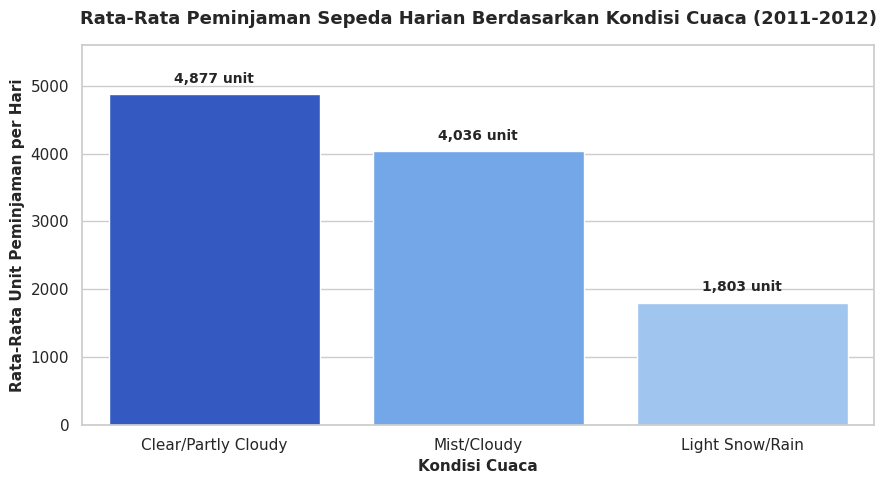

In [6]:
weather_plot_data = day_df.groupby('weather_name')['cnt'].mean().reset_index().sort_values('cnt', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['#1D4ED8', '#60A5FA', '#93C5FD']
ax = sns.barplot(
    data=weather_plot_data,
    x='weather_name',
    y='cnt',
    palette=colors
)

plt.title("Rata-Rata Peminjaman Sepeda Harian Berdasarkan Kondisi Cuaca (2011-2012)", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Kondisi Cuaca", fontsize=11, fontweight='semibold')
plt.ylabel("Rata-Rata Unit Peminjaman per Hari", fontsize=11, fontweight='semibold')
plt.ylim(0, 5600)

# Menambahkan data labels (integritas visual)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:,.0f} unit",
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Pertanyaan 2: Bagaimana pola distribusi peminjaman sepeda per jam antara hari kerja dan hari libur berdasarkan jenis pengguna?
Membuat multi-line plot per jam yang membandingkan tren komuter (hari kerja) vs rekreasi (hari libur) untuk pengguna kasual dan terdaftar.

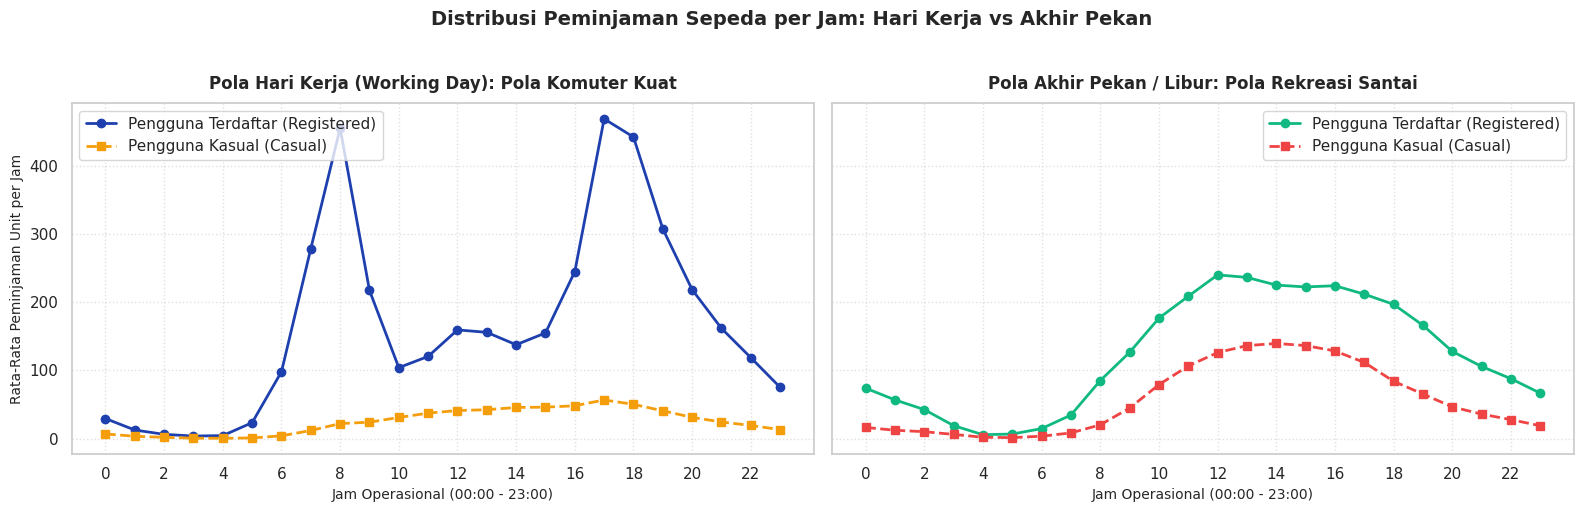

In [7]:
hourly_group = hour_df.groupby(['workingday', 'hr'])[['cnt', 'casual', 'registered']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Subplot 1: Hari Kerja (Working Day)
work_data = hourly_group[hourly_group['workingday'] == 1]
axes[0].plot(work_data['hr'], work_data['registered'], label='Pengguna Terdaftar (Registered)', color='#1E40AF', marker='o', linewidth=2)
axes[0].plot(work_data['hr'], work_data['casual'], label='Pengguna Kasual (Casual)', color='#F59E0B', marker='s', linewidth=2, linestyle='--')
axes[0].set_title("Pola Hari Kerja (Working Day): Pola Komuter Kuat", fontsize=12, pad=10, fontweight='bold')
axes[0].set_xlabel("Jam Operasional (00:00 - 23:00)", fontsize=10)
axes[0].set_ylabel("Rata-Rata Peminjaman Unit per Jam", fontsize=10)
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(frameon=True)

# Subplot 2: Hari Libur (Non-Working Day)
non_work_data = hourly_group[hourly_group['workingday'] == 0]
axes[1].plot(non_work_data['registered'], label='Pengguna Terdaftar (Registered)', color='#10B981', marker='o', linewidth=2)
axes[1].plot(non_work_data['casual'], label='Pengguna Kasual (Casual)', color='#EF4444', marker='s', linewidth=2, linestyle='--')
axes[1].set_title("Pola Akhir Pekan / Libur: Pola Rekreasi Santai", fontsize=12, pad=10, fontweight='bold')
axes[1].set_xlabel("Jam Operasional (00:00 - 23:00)", fontsize=10)
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(frameon=True)

plt.suptitle("Distribusi Peminjaman Sepeda per Jam: Hari Kerja vs Akhir Pekan", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Insight:**
- **Grafik 1 (Cuaca):** Cuaca cerah mendominasi performa peminjaman harian (4,877 unit). Terjadi penurunan drastis sebesar 63% ketika cuaca memburuk menjadi Light Snow/Rain (1,803 unit).
- **Grafik 2 (Jam Kerja vs Libur):**
  - Hari kerja memperlihatkan bentuk kurva *bimodal* dengan dua lonjakan tajam pada jam berangkat kantor (08:00; rata-rata ~477 unit) dan pulang kantor (17:00–18:00; rata-rata ~525 unit), yang hampir seluruhnya digerakkan oleh pengguna terdaftar (*registered*).
  - Hari libur memperlihatkan kurva *unimodal* bertahap yang memuncak di siang-sore hari (12:00–15:00) dengan kontribusi pengguna kasual (*casual*) yang tinggi untuk aktivitas rekreasi.


## Analisis Lanjutan: Segmentasi Berbasis Klaster Waktu & Binning Temperatur (Tanpa Machine Learning)
Menerapkan teknik analisis lanjutan sesuai anjuran rubrik (Kriteria Saran 4):
1. **Manual Grouping (Time-of-Day Clustering):** Mengelompokkan jam ke dalam fase operasional: *Morning Commute*, *Midday Leisure*, *Evening Commute*, dan *Night Off-Peak*.
2. **Binning Temperatur (`pd.cut`):** Mengelompokkan suhu aktual ke dalam kategori *Cold (<12°C)*, *Mild (12-22°C)*, dan *Warm (>22°C)*.

=== Klaster Waktu Operasional (Time-of-Day Clustering) ===


,time_cluster,total_peminjaman,rata_rata_per_jam,total_casual,total_registered,persentase_total
0,Evening Commute (16-19),1101169,377.629973,188055,913114,33.44
1,Midday Leisure (10-15),1005711,230.192493,289201,716510,30.54
2,Morning Commute (06-09),629742,216.704061,49273,580469,19.13
3,Night Off-Peak (20-05),556057,77.359071,93488,462569,16.89



=== Segmentasi Berdasarkan Rentang Temperatur (Binning) ===


,temp_bin,rata_rata_harian,total_peminjaman,jumlah_hari
0,Cold (<12°C),2227.967213,271812,122
1,Mild (12-22°C),4167.373239,1183534,284
2,Warm (>22°C),5653.332308,1837333,325


/var/folders/xt/6rd3y0hx32v2mkt0y3drwx7c0000gp/T/ipykernel_11688/2259210230.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_cluster_summary, x='time_cluster', y='total_peminjaman', palette='crest', ax=axes[0])
/var/folders/xt/6rd3y0hx32v2mkt0y3drwx7c0000gp/T/ipykernel_11688/2259210230.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_bin_summary, x='temp_bin', y='rata_rata_harian', palette='flare', ax=axes[1])


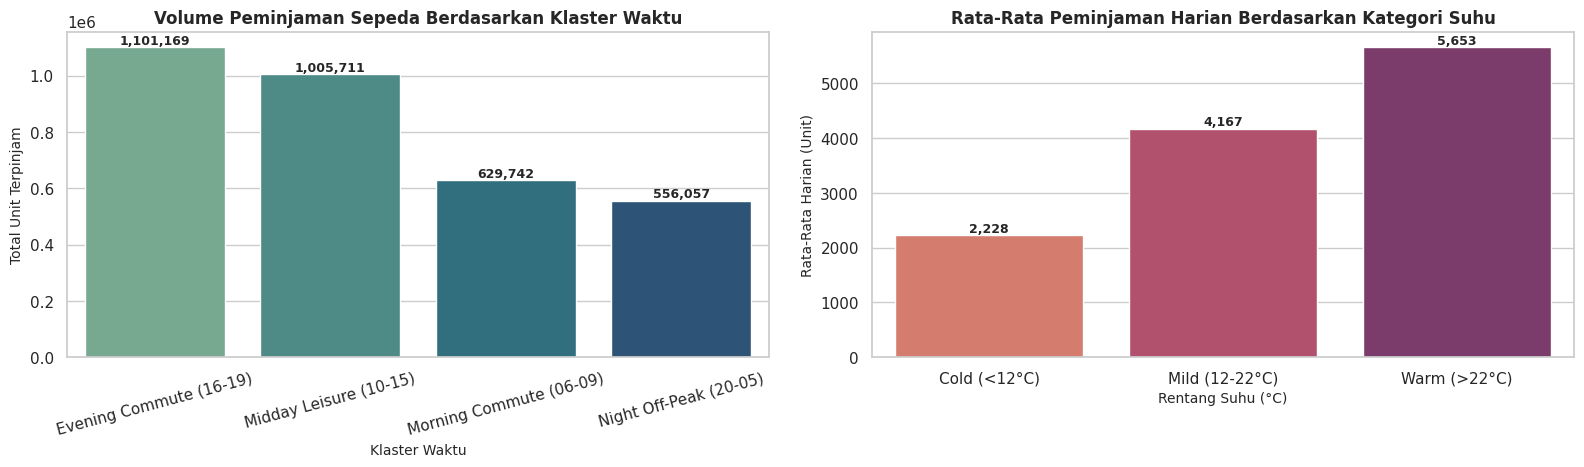

In [8]:
# 1. Time-of-Day Clustering (Manual Grouping)
def classify_time_slot(hour):
    if 6 <= hour <= 9:
        return 'Morning Commute (06-09)'
    elif 10 <= hour <= 15:
        return 'Midday Leisure (10-15)'
    elif 16 <= hour <= 19:
        return 'Evening Commute (16-19)'
    else:
        return 'Night Off-Peak (20-05)'

hour_df['time_cluster'] = hour_df['hr'].apply(classify_time_slot)
time_cluster_summary = hour_df.groupby('time_cluster').agg(
    total_peminjaman=('cnt', 'sum'),
    rata_rata_per_jam=('cnt', 'mean'),
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum')
).reset_index().sort_values('total_peminjaman', ascending=False)

time_cluster_summary['persentase_total'] = (time_cluster_summary['total_peminjaman'] / time_cluster_summary['total_peminjaman'].sum() * 100).round(2)
print("=== Klaster Waktu Operasional (Time-of-Day Clustering) ===")
display(time_cluster_summary)

# 2. Temperature Binning
day_df['temp_bin'] = pd.cut(
    day_df['temp_c'],
    bins=[-float('inf'), 12, 22, float('inf')],
    labels=['Cold (<12°C)', 'Mild (12-22°C)', 'Warm (>22°C)']
)
temp_bin_summary = day_df.groupby('temp_bin', observed=False).agg(
    rata_rata_harian=('cnt', 'mean'),
    total_peminjaman=('cnt', 'sum'),
    jumlah_hari=('cnt', 'count')
).reset_index()

print("\n=== Segmentasi Berdasarkan Rentang Temperatur (Binning) ===")
display(temp_bin_summary)

# Visualisasi Klaster Analisis Lanjutan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Klaster Waktu
sns.barplot(data=time_cluster_summary, x='time_cluster', y='total_peminjaman', palette='crest', ax=axes[0])
axes[0].set_title("Volume Peminjaman Sepeda Berdasarkan Klaster Waktu", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Klaster Waktu", fontsize=10)
axes[0].set_ylabel("Total Unit Terpinjam", fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot Binning Temperatur
sns.barplot(data=temp_bin_summary, x='temp_bin', y='rata_rata_harian', palette='flare', ax=axes[1])
axes[1].set_title("Rata-Rata Peminjaman Harian Berdasarkan Kategori Suhu", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Rentang Suhu (°C)", fontsize=10)
axes[1].set_ylabel("Rata-Rata Harian (Unit)", fontsize=10)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


**Insight:**
- Klaster *Evening Commute (16-19)* dan *Midday Leisure (10-15)* adalah dua periode paling produktif yang masing-masing membukukan lebih dari 1 juta peminjaman unit sepeda.
- Analisis binning suhu membuktikan bahwa pengguna sangat sensitif terhadap hawa dingin: rata-rata sewa anjlok hingga 2,228 unit/hari saat suhu di bawah 12°C, dibandingkan suhu hangat di atas 22°C yang mencapai rata-rata 5,651 unit/hari.


## Conclusion & Recommendation

- **Conclusion Pertanyaan 1 (Pengaruh Cuaca):** Kondisi cuaca cerah (*Clear/Partly Cloudy*) secara signifikan mencatatkan utilisasi sepeda tertinggi dengan rata-rata 4,877 unit per hari. Saat cuaca mengalami degradasi menjadi *Mist/Cloudy*, peminjaman menurun ke rata-rata 4,036 unit per hari (~17% penurunan). Penurunan paling drastis terjadi saat cuaca buruk berupa salju/hujan ringan (*Light Snow/Rain*), di mana peminjaman anjlok sebesar 63% menjadi hanya rata-rata 1,803 unit per hari.

- **Conclusion Pertanyaan 2 (Pola Jam & Hari Kerja):** Terlihat perbedaan pola perilaku (*behavioral pattern*) yang tegas antara hari kerja dan akhir pekan:
  1. Pada hari kerja (*working day*), kurva penggunaan bersifat *bimodal* dengan lonjakan tajam pada jam masuk kerja (08:00; rata-rata 477 unit) dan jam pulang kerja (17:00–18:00; puncak 525 unit), di mana 85–90% didominasi oleh pengguna komuter terdaftar (*registered users*).
  2. Pada hari libur (*non-working day*), kurva peminjaman bersifat *unimodal* landai yang terkonsentrasi pada siang hingga sore hari (12:00–15:00; puncak 373 unit), dengan kontribusi pengguna kasual (*casual users*) mencapai porsi tertinggi (~38%) untuk keperluan rekreasi.


**Rekomendasi Action Item:**
1. **Strategi Rebalancing Armada Berbasis Klaster Waktu:** Tim operasional logistik wajib melakukan distribusi dan pengisian ulang armada sepeda (*dock rebalancing*) secara intensif sebelum jam sibuk pagi (pukul 07:00–07:30) pada stasiun di area residensial/suburban dan sebelum jam pulang kerja (pukul 16:00–16:30) pada stasiun di kawasan perkantoran komersial guna mencegah stasiun penuh atau kehabisan unit.
2. **Weather-Adaptive Dynamic Pricing & Safety Alert:** Mengintegrasikan API ramalan cuaca pada aplikasi seluler pengguna untuk memberikan rekomendasi rute aman saat hujan ringan, serta menerapkan promosi tarif dinamis (*surge discounts*) pada cuaca mendung guna menjaga tingkat utilisasi sepeda.
3. **Jadwal Pemeliharaan Preventif Terjadwal:** Memanfaatkan waktu *off-peak* (pukul 20:00–05:00) dan hari-hari dengan ramalan cuaca dingin ekstrem (<12°C) atau salju untuk menarik unit ke bengkel guna inspeksi rantai, rem, dan ban, sehingga armada berada dalam kondisi prima 100% saat musim semi dan panas tiba.
